In [1]:
import pandas as pd

df = pd.read_excel("DF_FINAL.xlsx")

df.head()

calles_base = [
        "Calle Alberto Aguilera",
        "Calle Atocha",
        "Calle Gran Vía",
        "Calle Hortaleza",
        "Calle Mayor",
        "Calle Princesa",
        "Paseo Infanta Isabel",
        "Paseo de El Prado"
]

calles_oeste = []

for base in calles_base:
    for col in df.columns:
        if base in col:
            calles_oeste.append(col)

L = 3  # número de lags

X = pd.DataFrame()

for street in calles_oeste:
    for lag in range(1, L + 1):
        X[f"{street}_t-{lag}"] = df[street].shift(lag)

# Variables externas reales
X["AEMET_tmed"] = df["AEMET_tmed"]
X["AEMET_prec"] = df["AEMET_prec"]
X["dia_semana"] = df["dia_semana"]
X["festivo"] = df["festivo"]

# Convertir variables categóricas a numéricas
X["dia_semana"] = X["dia_semana"].map({
    "lunes": 0,
    "martes": 1,
    "miércoles": 2,
    "jueves": 3,
    "viernes": 4,
    "sábado": 5,
    "domingo": 6
})

X["festivo"] = X["festivo"].map({
    "no": 0,
    "sí": 1
})


y_col = [col for col in df.columns if "Calle Princesa" in col][0]
y = df[y_col]

# Limpiar NaNs
X = X.dropna()
y = y.loc[X.index]

In [2]:
split = int(len(X) * 0.8)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]

y_train = y.iloc[:split]
y_test  = y.iloc[split:]

In [3]:
X_train

,Calle Alberto Aguilera_E-O_t-1,Calle Alberto Aguilera_E-O_t-2,Calle Alberto Aguilera_E-O_t-3,Calle Alberto Aguilera_O-E_t-1,Calle Alberto Aguilera_O-E_t-2,Calle Alberto Aguilera_O-E_t-3,Calle Atocha_E-O_t-1,Calle Atocha_E-O_t-2,Calle Atocha_E-O_t-3,Calle Gran Vía_E-O_t-1,...,Paseo de El Prado_N-S_t-1,Paseo de El Prado_N-S_t-2,Paseo de El Prado_N-S_t-3,Paseo de El Prado_S-N_t-1,Paseo de El Prado_S-N_t-2,Paseo de El Prado_S-N_t-3,AEMET_tmed,AEMET_prec,dia_semana,festivo
3,225.0,275.0,475.0,181.0,246.0,329.0,393.0,531.0,547.0,484.0,...,890.0,864.0,1743.0,320.0,423.0,587.0,19.6,0.0,4.0,0.0
4,219.0,225.0,275.0,165.0,181.0,246.0,300.0,393.0,531.0,391.0,...,688.0,890.0,864.0,413.0,320.0,423.0,19.6,0.0,4.0,0.0
5,236.0,219.0,225.0,190.0,165.0,181.0,271.0,300.0,393.0,322.0,...,563.0,688.0,890.0,355.0,413.0,320.0,19.6,0.0,4.0,0.0
6,362.0,236.0,219.0,487.0,190.0,165.0,246.0,271.0,300.0,288.0,...,506.0,563.0,688.0,1451.0,355.0,413.0,19.6,0.0,4.0,0.0
7,980.0,362.0,236.0,1422.0,487.0,190.0,347.0,246.0,271.0,434.0,...,779.0,506.0,563.0,3262.0,1451.0,355.0,19.6,0.0,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25046,1105.0,1048.0,1016.0,793.0,787.0,827.0,826.0,920.0,866.0,864.0,...,1994.0,1962.0,1748.0,1393.0,1380.0,1519.0,32.2,0.0,4.0,0.0
25047,1035.0,1105.0,1048.0,689.0,793.0,787.0,776.0,826.0,920.0,776.0,...,2370.0,1994.0,1962.0,1512.0,1393.0,1380.0,32.2,0.0,4.0,0.0
25048,753.0,1035.0,1105.0,567.0,689.0,793.0,675.0,776.0,826.0,729.0,...,2256.0,2370.0,1994.0,1195.0,1512.0,1393.0,32.2,0.0,4.0,0.0
25049,779.0,753.0,1035.0,611.0,567.0,689.0,703.0,675.0,776.0,767.0,...,1880.0,2256.0,2370.0,1189.0,1195.0,1512.0,32.2,0.0,4.0,0.0


In [4]:
with pd.ExcelWriter("dataset_RF_Princesa.xlsx") as writer:
    X_train.to_excel(writer, sheet_name="X_train")
    X_test.to_excel(writer, sheet_name="X_test")
    y_train.to_excel(writer, sheet_name="y_train")
    y_test.to_excel(writer, sheet_name="y_test")

In [5]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    min_samples_leaf=20,
    random_state=0,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=20, n_estimators=400,
                      n_jobs=-1, random_state=0)

In [6]:
# Predicción en test
y_pred = rf.predict(X_test)

# Predicción próxima hora
X_next = X.iloc[[-1]]
y_next = rf.predict(X_next)

comparacion = pd.DataFrame({
    "Real": y_test,
    "Predicho": y_pred
})

comparacion.to_excel("comparacion_predicciones.xlsx", index=True)

print("Predicción tráfico en Princesa (N-S) próxima hora:", y_next[0])

Predicción tráfico en Princesa (N-S) próxima hora: 299.7185828924237


In [7]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# MAE y RMSE normales
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Eliminar filas donde el valor real sea 0 para calcular MAPE
mask = y_test != 0
y_test_mape = y_test[mask]
y_pred_mape = y_pred[mask]

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape_val = mape(y_test_mape, y_pred_mape)

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE (sin valores reales = 0): {mape_val:.2f} %")

MAE: 35.55
RMSE: 53.87
MAPE (sin valores reales = 0): 12.70 %


In [8]:
importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(importances.head(10))

Calle Princesa_N-S_t-1            0.674267
Calle Alberto Aguilera_O-E_t-1    0.236176
Paseo de El Prado_S-N_t-1         0.026975
Calle Alberto Aguilera_E-O_t-2    0.008773
Calle Alberto Aguilera_E-O_t-3    0.005279
Calle Princesa_N-S_t-2            0.003626
Calle Alberto Aguilera_O-E_t-2    0.003587
Calle Princesa_N-S_t-3            0.003573
Paseo Infanta Isabel_O-E_t-3      0.003075
Paseo Infanta Isabel_E-O_t-2      0.002957
dtype: float64


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=0,
    n_jobs=-1,
    scoring="neg_mean_absolute_error"
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": perm.importances_mean
}).sort_values("importance", ascending=False)

perm_df.head(10)


,feature,importance
21,Calle Princesa_N-S_t-1,68.763817
3,Calle Alberto Aguilera_O-E_t-1,43.890248
36,Paseo de El Prado_S-N_t-1,9.975786
0,Calle Alberto Aguilera_E-O_t-1,2.194481
31,Paseo Infanta Isabel_O-E_t-2,1.255405
2,Calle Alberto Aguilera_E-O_t-3,1.072256
1,Calle Alberto Aguilera_E-O_t-2,1.055309
4,Calle Alberto Aguilera_O-E_t-2,0.821906
32,Paseo Infanta Isabel_O-E_t-3,0.639099
6,Calle Atocha_E-O_t-1,0.473731


In [10]:
top_k = 8
top_features = perm_df.head(top_k)
top_features


,feature,importance
21,Calle Princesa_N-S_t-1,68.763817
3,Calle Alberto Aguilera_O-E_t-1,43.890248
36,Paseo de El Prado_S-N_t-1,9.975786
0,Calle Alberto Aguilera_E-O_t-1,2.194481
31,Paseo Infanta Isabel_O-E_t-2,1.255405
2,Calle Alberto Aguilera_E-O_t-3,1.072256
1,Calle Alberto Aguilera_E-O_t-2,1.055309
4,Calle Alberto Aguilera_O-E_t-2,0.821906


In [11]:
top_streets = (
    top_features["feature"]
    .str.split("_")
    .str[0]
    .value_counts()
)
top_streets

feature
Calle Alberto Aguilera    5
Calle Princesa            1
Paseo de El Prado         1
Paseo Infanta Isabel      1
Name: count, dtype: int64

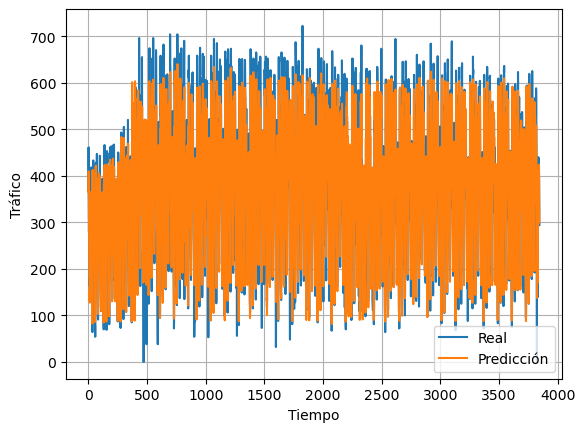

In [12]:
import matplotlib.pyplot as plt
plt.figure()
plt.plot(y_test.values, label='Real')
plt.plot(y_pred, label='Predicción')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Tráfico')
plt.grid()
plt.show()

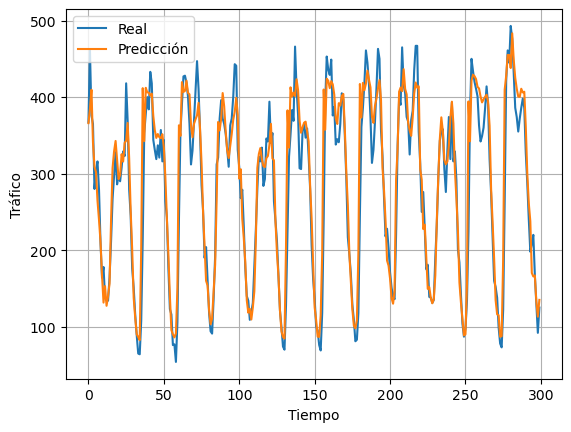

In [13]:
n = 300  # número de puntos a mostrar

plt.figure()
plt.plot(y_test.values[:n], label='Real')
plt.plot(y_pred[:n], label='Predicción')

plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Tráfico')
plt.grid()

plt.show()

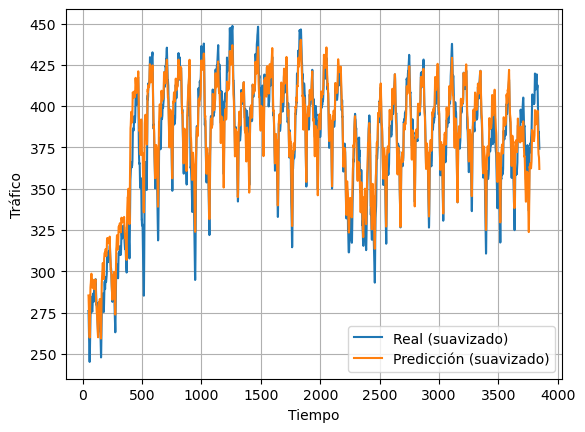

In [14]:
import pandas as pd

y_real_smooth = pd.Series(y_test.values).rolling(window=50).mean()
y_pred_smooth = pd.Series(y_pred).rolling(window=50).mean()

plt.figure()
plt.plot(y_real_smooth, label='Real (suavizado)')
plt.plot(y_pred_smooth, label='Predicción (suavizado)')

plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Tráfico')
plt.grid()

plt.show()

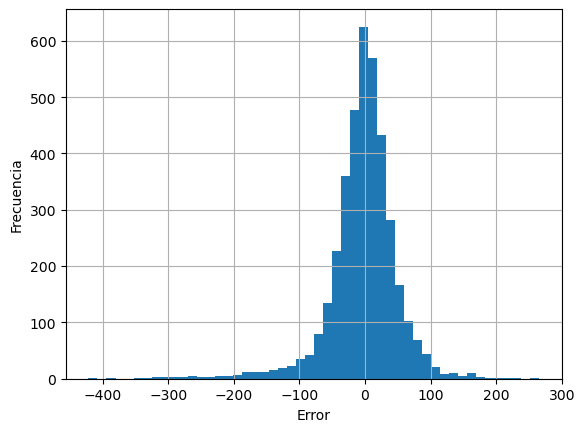

In [15]:
errores = y_test.values - y_pred

plt.figure()
plt.hist(errores, bins=50)

plt.xlabel('Error')
plt.ylabel('Frecuencia')

plt.grid()
plt.show()

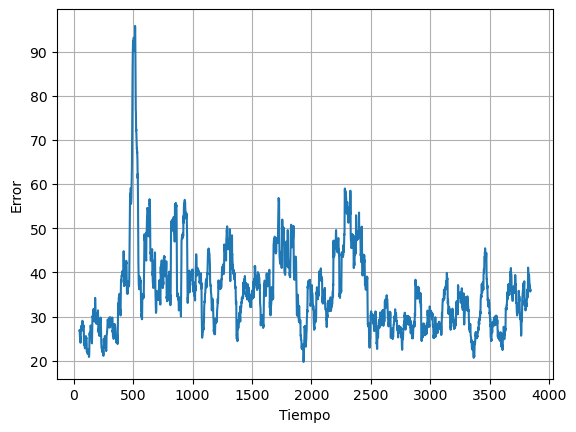

In [16]:
errores = abs(y_test.values - y_pred)
errores_smooth = pd.Series(errores).rolling(window=50).mean()

plt.figure()
plt.plot(errores_smooth)

plt.xlabel('Tiempo')
plt.ylabel('Error')

plt.grid()
plt.show()

In [17]:
from pathlib import Path

# Cambiar estos dos valores en cada notebook
modelo = "RF"
calle = "Calle Princesa"

# Carpeta donde se guardarán las importancias
output_dir = Path("importancias_variables")
output_dir.mkdir(exist_ok=True)

# Guardar todas las variables, no solo el top 10
perm_df_export = perm_df.copy()
perm_df_export["modelo"] = modelo
perm_df_export["calle"] = calle

# Nombre limpio para el archivo
nombre_archivo = f"{modelo}_{calle}".replace(" ", "_").replace("á", "a").replace("é", "e")
nombre_archivo = nombre_archivo.replace("í", "i").replace("ó", "o").replace("ú", "u")

perm_df_export.to_csv(output_dir / f"{nombre_archivo}.csv", index=False)

print(f"Archivo guardado: {output_dir / f'{nombre_archivo}.csv'}")

Archivo guardado: importancias_variables\RF_Calle_Princesa.csv


In [18]:
calle_objetivo = "Calle Princesa"   # cámbialo según el notebook
modelo = "RF"                # opcional, para tenerlo identificado

In [19]:
import pandas as pd
import unicodedata

def normalizar_texto(texto):
    texto = str(texto).lower()
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )
    return texto

def clasificar_variable(feature, calle_objetivo):
    f = normalizar_texto(feature)
    calle = normalizar_texto(calle_objetivo)

    # Variables meteorológicas
    if any(palabra in f for palabra in [
        'aemet', 'tmed', 'temp', 'temperatura', 'prec', 'precipitacion',
        'humedad', 'viento', 'presion', 'radiacion'
    ]):
        return 'Variables meteorológicas'

    # Variables de calendario
    if any(palabra in f for palabra in [
        'dia_semana', 'festivo', 'mes', 'hora', 'fin_semana'
    ]):
        return 'Variables de calendario'

    # Retardos de la propia calle
    if calle in f:
        return 'Retardos propia calle'

    # Resto de variables de tráfico
    return 'Retardos otras calles'

In [20]:
perm_df_aux = perm_df.copy()

perm_df_aux["modelo"] = modelo
perm_df_aux["calle"] = calle_objetivo

perm_df_aux["tipo_variable"] = perm_df_aux["feature"].apply(
    lambda x: clasificar_variable(x, calle_objetivo)
)

perm_df_aux.head(15)

,feature,importance,modelo,calle,tipo_variable
21,Calle Princesa_N-S_t-1,68.763817,RF,Calle Princesa,Retardos propia calle
3,Calle Alberto Aguilera_O-E_t-1,43.890248,RF,Calle Princesa,Retardos otras calles
36,Paseo de El Prado_S-N_t-1,9.975786,RF,Calle Princesa,Retardos otras calles
0,Calle Alberto Aguilera_E-O_t-1,2.194481,RF,Calle Princesa,Retardos otras calles
31,Paseo Infanta Isabel_O-E_t-2,1.255405,RF,Calle Princesa,Retardos otras calles
2,Calle Alberto Aguilera_E-O_t-3,1.072256,RF,Calle Princesa,Retardos otras calles
1,Calle Alberto Aguilera_E-O_t-2,1.055309,RF,Calle Princesa,Retardos otras calles
4,Calle Alberto Aguilera_O-E_t-2,0.821906,RF,Calle Princesa,Retardos otras calles
32,Paseo Infanta Isabel_O-E_t-3,0.639099,RF,Calle Princesa,Retardos otras calles
6,Calle Atocha_E-O_t-1,0.473731,RF,Calle Princesa,Retardos otras calles


In [21]:
perm_df_aux["importance_pos"] = perm_df_aux["importance"].clip(lower=0)

In [22]:
resumen_tipos = (
    perm_df_aux
    .groupby("tipo_variable")["importance_pos"]
    .sum()
    .reset_index()
)

resumen_tipos["porcentaje"] = (
    100 * resumen_tipos["importance_pos"] / resumen_tipos["importance_pos"].sum()
)

resumen_tipos = resumen_tipos.sort_values("porcentaje", ascending=False)

resumen_tipos

,tipo_variable,importance_pos,porcentaje
1,Retardos propia calle,69.404491,52.307674
0,Retardos otras calles,63.013898,47.491314
2,Variables de calendario,0.255198,0.192334
3,Variables meteorológicas,0.011514,0.008678


In [23]:
meteo_df = perm_df_aux[perm_df_aux["tipo_variable"] == "Variables meteorológicas"] \
    .sort_values("importance", ascending=False)

meteo_df.head(20)

,feature,importance,modelo,calle,tipo_variable,importance_pos
39,AEMET_tmed,0.011514,RF,Calle Princesa,Variables meteorológicas,0.011514
40,AEMET_prec,-0.006411,RF,Calle Princesa,Variables meteorológicas,0.000000


In [24]:
meteo_total = meteo_df["importance_pos"].sum()
print("Importancia positiva acumulada de meteorología:", meteo_total)

Importancia positiva acumulada de meteorología: 0.011514097673793345


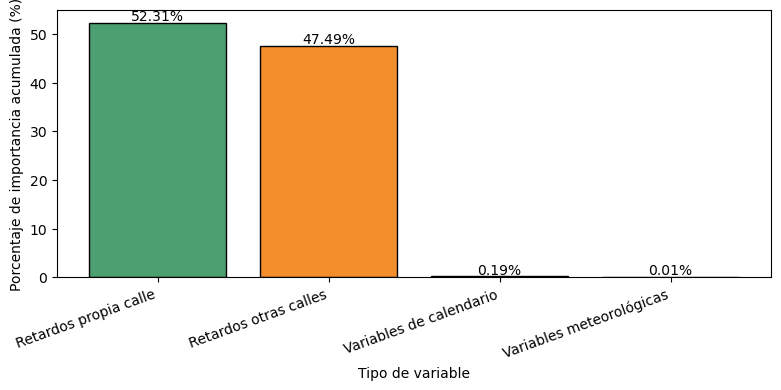

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(resumen_tipos["tipo_variable"], resumen_tipos["porcentaje"],
        color=['#4C9F70', '#F28E2B', '#8E63CE', '#BDBDBD'],
        edgecolor='black')

plt.ylabel("Porcentaje de importancia acumulada (%)")
plt.xlabel("Tipo de variable")

for i, v in enumerate(resumen_tipos["porcentaje"]):
    plt.text(i, v + 0.5, f"{v:.2f}%", ha='center')

plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()